# Laboratorio 3 — Deep Learning: Reconocimiento de Lenguaje de Señas (ASL)
### CC3084 Data Science · UVG · Semestre II 2026

**Entrega:** Avance (pasaporte) — *Análisis Exploratorio, Preprocesamiento y Selección de modelos.*

**Integrantes del grupo:**
- _Nicolas Concua_
- _Felipe Aguilar_

---

## Contexto — SignBridge

**SignBridge** es una startup guatemalteca de tecnología inclusiva que desarrolla un
traductor de **Lenguaje de Señas Americano (ASL)** en tiempo real para apps educativas.
Como equipo de Data Science, construimos y evaluamos el primer prototipo del motor de
reconocimiento: un **clasificador de letras del alfabeto ASL** a partir de fotografías de
manos. El objetivo del producto es reconocer, **letra por letra**, las señas que hace una
persona frente a una cámara.

Trabajamos con el dataset **ASL Alphabet** de Kaggle
([grassknoted/asl-alphabet](https://www.kaggle.com/datasets/grassknoted/asl-alphabet)):
fotografías reales `.jpg` de **200×200 px a color**, organizadas en carpetas por clase.
Contiene ~87,000 imágenes en **29 clases**: las 26 letras (A–Z) más `SPACE`, `DELETE` y
`NOTHING`.

> **Alcance de este avance.** Este cuaderno cubre los ejercicios **1 (ejemplos y
> variabilidad)**, **2 (análisis exploratorio)** y **3 (preprocesamiento)**, más la
> **selección de modelos y el plan** para el procesamiento de imágenes. El entrenamiento
> de los modelos (ejercicios 4–9) queda para la entrega final.


## 0. Instalación de dependencias

Si te falta alguna librería, **descomenta y ejecuta** la siguiente celda. El notebook está
pensado para correr en un entorno con **Python 3.13** (TensorFlow todavía no publica ruedas
para 3.14). Recomendado: crear un `.venv` propio para el Lab 3.


In [1]:
# %pip install numpy pandas matplotlib seaborn scikit-learn pillow
# %pip install tensorflow            # se usa en la entrega final (modelos CNN)

## 1. Configuración: imports, semillas y rutas

Fijamos las semillas para que el muestreo de imágenes y las particiones sean
**reproducibles**, y detectamos automáticamente la carpeta del dataset.


In [2]:
import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# --- Localizar la carpeta de entrenamiento del dataset ASL ---
# Estructura esperada:  data/asl-alphabet/asl_alphabet_train/asl_alphabet_train/<CLASE>/*.jpg
CANDIDATOS = [
    "../data/asl-alphabet/asl_alphabet_train/asl_alphabet_train",
    "data/asl-alphabet/asl_alphabet_train/asl_alphabet_train",
    "../data/asl_alphabet_train/asl_alphabet_train",
]
TRAIN_DIR = next((p for p in CANDIDATOS if os.path.isdir(p)), None)
assert TRAIN_DIR is not None, (
    "No se encontró la carpeta de entrenamiento. Descarga el dataset ASL Alphabet de "
    "Kaggle y colócalo en Lab3-DataScience/data/  (ver .gitignore: data/ no se versiona)."
)

CLASES = sorted(os.listdir(TRAIN_DIR))
CLASES = [c for c in CLASES if os.path.isdir(os.path.join(TRAIN_DIR, c))]
print(f"Carpeta de datos : {TRAIN_DIR}")
print(f"Clases detectadas: {len(CLASES)}")
print(CLASES)

Carpeta de datos : ../data/asl-alphabet/asl_alphabet_train/asl_alphabet_train
Clases detectadas: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## 2. Ejercicio 1 — Ejemplos del alfabeto ASL y variabilidad intra-clase

Mostramos varias muestras de **6 letras distintas**. Cada **fila** es una letra y cada
**columna** una foto diferente de esa misma seña, para observar la **variabilidad dentro de
una clase**: cambios de iluminación, encuadre, distancia de la mano y fondo, aun cuando la
seña es la misma.


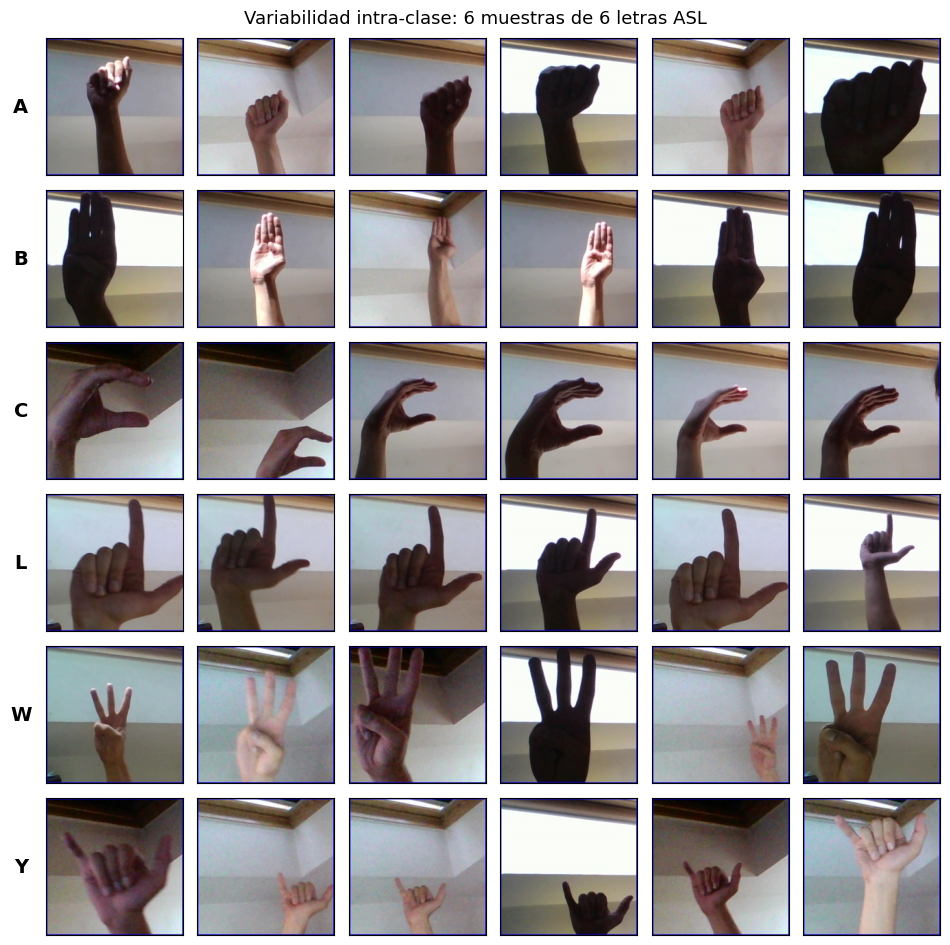

In [3]:
def cargar_muestras(clase, n, semilla=SEED):
    # Devuelve n rutas de imagenes al azar (reproducible) para una clase.
    carpeta = os.path.join(TRAIN_DIR, clase)
    archivos = [f for f in os.listdir(carpeta) if f.lower().endswith(".jpg")]
    rng = random.Random(semilla + hash(clase) % 1000)
    elegidos = rng.sample(archivos, min(n, len(archivos)))
    return [os.path.join(carpeta, f) for f in elegidos]

LETRAS_DEMO = ["A", "B", "C", "L", "W", "Y"]   # 6 letras visualmente distintas
N_MUESTRAS = 6

fig, axes = plt.subplots(len(LETRAS_DEMO), N_MUESTRAS,
                         figsize=(N_MUESTRAS * 1.6, len(LETRAS_DEMO) * 1.6))
for i, letra in enumerate(LETRAS_DEMO):
    rutas = cargar_muestras(letra, N_MUESTRAS)
    for j, ruta in enumerate(rutas):
        ax = axes[i, j]
        ax.imshow(Image.open(ruta))
        ax.set_xticks([]); ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(letra, rotation=0, labelpad=18, fontsize=14,
                          va="center", fontweight="bold")
fig.suptitle("Variabilidad intra-clase: 6 muestras de 6 letras ASL", fontsize=13)
plt.tight_layout()
plt.show()

**Interpretación.** Dentro de una misma letra las fotos **no son idénticas**: varía la
iluminación (manos más claras u oscuras), la posición y el tamaño de la mano en el encuadre,
y ligeras rotaciones de la muñeca. El fondo, en cambio, es bastante **constante** (pared
clara) — una pista de que el modelo podría apoyarse en el fondo en lugar de la mano, algo a
vigilar. Esta variabilidad es justo lo que un clasificador robusto debe aprender a ignorar
para quedarse con la **forma de la mano**, que es lo que define la seña.
